<a href="https://colab.research.google.com/github/Geovana2302/IA-Generativas-Aplicada-a-Programacao-ChatGPT/blob/main/Atividade_Aprendizado_de_M%C3%A1quina_n%C3%A3o_Supervisionado.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação com Dry Bean Dataset
### Projeto de Machine Learning - Classificação Multiclasse

In [ ]:
# Bibliotecas principais
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Pré-processamento
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler

# Métricas
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
# Carregar o arquivo CSV

df = pd.read_csv("Dry_Bean_Dataset.csv")

# Visualizar as 5 primeiras linhas
df.head()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [ ]:
# Verificar informações gerais do dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 17 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Area             13611 non-null  int64  
 1   Perimeter        13611 non-null  float64
 2   MajorAxisLength  13611 non-null  float64
 3   MinorAxisLength  13611 non-null  float64
 4   AspectRation     13611 non-null  float64
 5   Eccentricity     13611 non-null  float64
 6   ConvexArea       13611 non-null  int64  
 7   EquivDiameter    13611 non-null  float64
 8   Extent           13611 non-null  float64
 9   Solidity         13611 non-null  float64
 10  roundness        13611 non-null  float64
 11  Compactness      13611 non-null  float64
 12  ShapeFactor1     13611 non-null  float64
 13  ShapeFactor2     13611 non-null  float64
 14  ShapeFactor3     13611 non-null  float64
 15  ShapeFactor4     13611 non-null  float64
 16  Class            13611 non-null  object 
dtypes: float64(1

In [ ]:
# Estatísticas descritivas
df.describe()

,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


In [ ]:
# Verificar quantidade de amostras por classe
df["Class"].value_counts()

,count
Class,
DERMASON,3546
SIRA,2636
SEKER,2027
HOROZ,1928
CALI,1630
BARBUNYA,1322
BOMBAY,522


In [ ]:
# Separar variáveis independentes (X) e variável alvo (y)

X = df.drop("Class", axis=1)  # Características
y = df["Class"]               # Rótulo

In [ ]:
# Padronizar dados (muito importante para KNN)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Dividir dados
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42
)

In [ ]:
# Criar modelos
knn = KNeighborsClassifier(n_neighbors=5)
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)

# Treinar
knn.fit(X_treino, y_treino)
dt.fit(X_treino, y_treino)
rf.fit(X_treino, y_treino)

RandomForestClassifier(random_state=42)

In [ ]:
# Função para avaliar modelo
def avaliar_modelo(modelo, nome):
    y_pred = modelo.predict(X_teste)
    print(f"\nModelo: {nome}")
    print("Acurácia:", accuracy_score(y_teste, y_pred))
    print(classification_report(y_teste, y_pred))

avaliar_modelo(knn, "KNN")
avaliar_modelo(dt, "Decision Tree")
avaliar_modelo(rf, "Random Forest")


Modelo: KNN
Acurácia: 0.9214005876591577
              precision    recall  f1-score   support

    BARBUNYA       0.95      0.91      0.93       395
      BOMBAY       1.00      1.00      1.00       161
        CALI       0.92      0.94      0.93       479
    DERMASON       0.90      0.91      0.91      1043
       HOROZ       0.97      0.95      0.96       588
       SEKER       0.95      0.95      0.95       619
        SIRA       0.86      0.87      0.87       799

    accuracy                           0.92      4084
   macro avg       0.94      0.93      0.93      4084
weighted avg       0.92      0.92      0.92      4084


Modelo: Decision Tree
Acurácia: 0.888099902056807
              precision    recall  f1-score   support

    BARBUNYA       0.89      0.90      0.89       395
      BOMBAY       1.00      1.00      1.00       161
        CALI       0.91      0.90      0.90       479
    DERMASON       0.88      0.88      0.88      1043
       HOROZ       0.93      0.93      

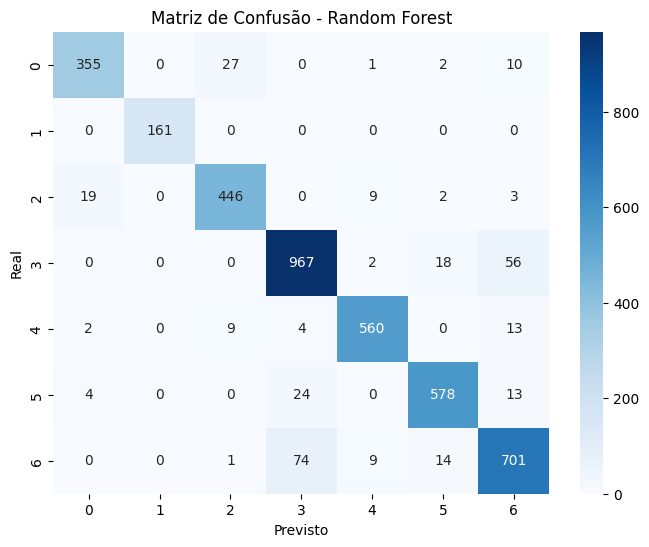

In [ ]:
# Escolher melhor modelo (exemplo: Random Forest)
y_pred_rf = rf.predict(X_teste)

cm = confusion_matrix(y_teste, y_pred_rf)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Previsto")
plt.ylabel("Real")
plt.show()

In [ ]:
# Cross Validation para modelo mais robusto

scores = cross_val_score(rf, X_scaled, y, cv=5)

print("Acurácia média (Cross Validation):", scores.mean())

Acurácia média (Cross Validation): 0.6117213882449637


## Conclusão

Após comparar os modelos KNN, Decision Tree e Random Forest:

- O modelo Random Forest apresentou melhor desempenho.
- A validação cruzada confirmou estabilidade do modelo.
- A normalização foi essencial para melhorar o KNN.

O modelo final escolhido foi o Random Forest por apresentar maior acurácia e melhor generalização.